# Predicting outcomes from ICU time series

This tutorial trains, evaluates and interprets prediction models on longitudinal ICU data with `ep.ml`.
We first predict in-hospital mortality from the first 48 hours of an ICU stay in the PhysioNet 2012 challenge {cite}`silva2012predicting` {cite}`goldberger2000physiobank`.
We then predict sepsis hour by hour in the [PhysioNet 2019 challenge](https://physionet.org/content/challenge-2019/1.0.0/).
Every step is set up so that the reported performance is the one we would expect on new patients.

```{note}
The deep learning models need PyTorch, which `pip install 'ehrapy[ml]'` installs.
```

## Environment setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import ehrapy as ep
import ehrdata as ed
import numpy as np
import pandas as pd

In [2]:
%matplotlib inline

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
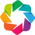

In [3]:
import holoviews as hv

hv.extension("bokeh")

## In-hospital mortality

### Data

The PhysioNet 2012 data holds 37 variables recorded hourly over the first 48 hours of 11,988 ICU stays.
The outcome `In-hospital_death` and static information such as age and sex are in `obs`.

In [4]:
edata = ed.dt.physionet2012()
edata

EHRData object with n_obs × n_vars × n_t = 11988 × 37 × 48
    obs: 'set', 'Age', 'Gender', 'Height', 'ICUType', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death'
    var: 'Parameter'
    tem: '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47'
    shape of .X: (11988, 37, 48)

`Length_of_stay` and `Survival` are only known after the stay, so they must never become features.
We only use age and sex next to the time series, and derive age groups for the subgroup analysis below.

In [5]:
edata.obs["sex"] = edata.obs["Gender"].map({0: "female", 1: "male"}).astype("category")
edata.obs["age_group"] = pd.cut(edata.obs["Age"], [0, 65, 80, np.inf], right=False, labels=["15-64", "65-79", "80-90"])
edata.obs["In-hospital_death"].value_counts(normalize=True)

In-hospital_death
0    0.857608
1    0.142392
Name: proportion, dtype: float64

### Patient-level split

{func}`~ehrapy.ml.split` assigns patients to a `train`, a `tuning` and a `held_out` set.
All observations of a patient end up in the same set, so a model is never evaluated on a patient it has seen during training.
Here every observation is one patient; with several stays per patient, pass their identifier as `patient_key`.
Stratifying on the outcome keeps the mortality of about 14% in every set.

In [6]:
ep.ml.split(edata, stratify="In-hospital_death")
pd.crosstab(edata.obs["split"], edata.obs["In-hospital_death"], normalize="index")

In-hospital_death,0,1
split,,
train,0.857602,0.142398
tuning,0.857620,0.142380
held_out,0.857620,0.142380


### Prediction task

A {class}`~ehrapy.ml.Task` defines what is predicted and from which timepoints.
We predict at hour 48 from a 42-hour observation window that ends 6 hours earlier.
The gap guards against leakage from the last hours before the prediction, whose measurements are often not available yet in practice and can already reflect the clinical decisions the model should anticipate.

In [7]:
task = ep.ml.Task("In-hospital_death", prediction_time=48, observation_window=42, gap=6)

### Gradient boosting on summaries

{func}`~ehrapy.ml.fit` summarizes every variable over the observation window with {func}`~ehrapy.preprocessing.summarize_measurements`.
Next to the minimum, maximum, mean and last value, `count` captures how often a variable was measured, which reflects how closely a patient was monitored, `std` its variability and `slope` its trend.
The median imputation and standardization of these features are fit on the training patients only, so no statistic of the held-out patients leaks into the model.

In [8]:
statistics = ["min", "max", "mean", "last", "count", "std", "slope"]
gradient_boosting = ep.ml.fit(edata, task, model="gradient_boosting", obs_keys=["Age", "sex"], statistics=statistics)
ep.ml.predict(edata, gradient_boosting, key_added="gradient_boosting")

### GRU on the raw time series

The GRU reads the hourly values of the observation window directly, together with whether every value was observed and the time since its last observation.
It stops training once its loss on the tuning set stops improving, which keeps the held-out set untouched until the evaluation.

In [9]:
gru = ep.ml.fit(edata, task, model="gru", obs_keys=["Age", "sex"])
ep.ml.predict(edata, gru, key_added="gru")

### Evaluation

{func}`~ehrapy.ml.evaluate` computes the metrics on the held-out patients with bootstrap confidence intervals.
It resamples patients rather than rows, so the intervals reflect how much the results vary between patients.

In [10]:
pd.concat({model: ep.ml.evaluate(edata, task, key=model) for model in ["gradient_boosting", "gru"]}, axis=1).round(3)

gradient_boosting                      gru           \
                                  value ci_lower ci_upper  value ci_lower   
metric                                                                      
auroc                             0.855    0.832    0.878  0.855    0.832   
auprc                             0.503    0.440    0.571  0.525    0.464   
brier                             0.094    0.084    0.105  0.091    0.082   
ece                               0.037    0.027    0.053  0.015    0.011   
calibration_intercept             0.314    0.142    0.488  0.073   -0.074   
calibration_slope                 0.798    0.707    0.896  1.034    0.923   
sensitivity                       0.258    0.207    0.313  0.281    0.230   
specificity                       0.972    0.964    0.980  0.977    0.969   
f1                                0.362    0.299    0.424  0.396    0.333   
positive_rate                     0.061    0.049    0.072  0.060    0.049   

                                
                      ci_upper  
metric                          
auroc                    0.877  
auprc                    0.593  
brier                    0.100  
ece                      0.032  
calibration_intercept    0.224  
calibration_slope        1.158  
sensitivity              0.345  
specificity              0.984  
f1                       0.462  
positive_rate            0.072

Both models reach an AUROC of 0.855 on the held-out patients with overlapping confidence intervals, so the GRU on the raw time series does not beat gradient boosting on well-chosen summaries here.
At the default threshold of 0.5, both flag only about 6% of patients and miss most deaths, so a threshold has to be chosen for the clinical use.

In [11]:
ep.pl.prediction_performance(edata, task, key="gradient_boosting")

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Layout
   .Overlay.I   :Overlay
      .Curve.I  :Curve   [False positive rate]   (True positive rate)
      .Curve.II :Curve   [x]   (y)
   .Overlay.II  :Overlay
      .Curve.I :Curve   [Recall]   (Precision)
      .HLine.I :HLine   [x,y]
   .Overlay.III :Overlay
      .Curve.I   :Curve   [Mean predicted probability]   (Observed frequency)
      .Scatter.I :Scatter   [x]   (y)
      .Curve.II  :Curve   [x]   (y)

The dashed line of the precision-recall curve is the mortality of the held-out patients, the AUPRC of a model that guesses.

### Subgroups and fairness

A good average performance can hide subgroups for which a model works worse.
With `groupby`, {func}`~ehrapy.ml.evaluate` computes every metric per subgroup and their largest difference between subgroups.
The difference of `positive_rate` is the demographic parity difference, and `equalized_odds` is the larger difference of sensitivity and specificity.

In [12]:
performance = ep.ml.evaluate(edata, task, key="gradient_boosting", groupby="age_group")
ep.pl.subgroup_performance(performance, metrics=["auroc", "calibration_slope", "sensitivity", "positive_rate"])

:Layout
   .Overlay.I   :Overlay
      .ErrorBars.I :ErrorBars   [age_group]   (auroc,lower,upper)
      .Scatter.I   :Scatter   [age_group]   (auroc)
   .Overlay.II  :Overlay
      .ErrorBars.I :ErrorBars   [age_group]   (calibration_slope,lower,upper)
      .Scatter.I   :Scatter   [age_group]   (calibration_slope)
   .Overlay.III :Overlay
      .ErrorBars.I :ErrorBars   [age_group]   (sensitivity,lower,upper)
      .Scatter.I   :Scatter   [age_group]   (sensitivity)
   .Overlay.IV  :Overlay
      .ErrorBars.I :ErrorBars   [age_group]   (positive_rate,lower,upper)
      .Scatter.I   :Scatter   [age_group]   (positive_rate)

In [13]:
performance.loc["difference"].round(3)

,value,ci_lower,ci_upper
metric,,,
auroc,0.095,0.036,0.163
auprc,0.057,0.018,0.221
brier,0.085,0.056,0.115
ece,0.042,0.022,0.092
calibration_intercept,0.084,0.053,0.608
calibration_slope,0.290,0.088,0.568
sensitivity,0.112,0.026,0.243
specificity,0.062,0.031,0.096
f1,0.094,0.023,0.259


The AUROC drops from 0.88 in patients under 65 to 0.78 in patients of 80 and older, whose predictions are also the least calibrated.
The model flags four times as many of the oldest patients, which partly reflects their higher mortality of 22% compared with 10%, so a demographic parity difference alone is no evidence of unfairness.
The wide confidence intervals of the differences show how few deaths every subgroup holds.

### Calibration

A predicted risk of 30% should mean that 30 of 100 such patients die.
The calibration slope below 1 shows that the predicted risks of gradient boosting are too extreme, and the positive intercept that they underestimate the risk on average.
{func}`~ehrapy.ml.calibrate` fits Platt scaling on the tuning set, which the model was not fit on, since calibrating on the held-out set would leak it into the evaluation.
Platt scaling keeps the order of the predictions and therefore the AUROC.

In [14]:
calibrated = ep.ml.calibrate(edata, gradient_boosting, method="platt")
ep.ml.predict(edata, calibrated, key_added="calibrated")
calibration_metrics = ["auroc", "brier", "ece", "calibration_intercept", "calibration_slope"]
pd.concat(
    {key: ep.ml.evaluate(edata, task, key=key).loc[calibration_metrics] for key in ["gradient_boosting", "calibrated"]},
    axis=1,
).round(3)

gradient_boosting                   calibrated           \
                                  value ci_lower ci_upper      value ci_lower   
metric                                                                          
auroc                             0.855    0.832    0.878      0.855    0.832   
brier                             0.094    0.084    0.105      0.093    0.083   
ece                               0.037    0.027    0.053      0.020    0.014   
calibration_intercept             0.314    0.142    0.488      0.119   -0.037   
calibration_slope                 0.798    0.707    0.896      0.985    0.873   

                                
                      ci_upper  
metric                          
auroc                    0.878  
brier                    0.102  
ece                      0.037  
calibration_intercept    0.269  
calibration_slope        1.105

Platt scaling brings the calibration slope close to 1 and roughly halves the expected calibration error, while the AUROC stays the same.

### Feature importance

{func}`~ehrapy.ml.permutation_importance` shuffles every variable, with all its summaries, between held-out patients and measures how much the AUROC drops.

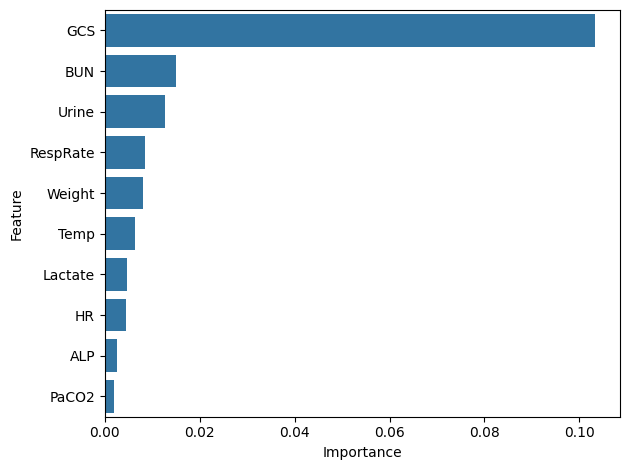

In [15]:
ep.ml.permutation_importance(edata, calibrated)
ep.pl.rank_features_supervised(edata, key="permutation_importance")

The Glasgow Coma Scale (GCS) dominates, followed by blood urea nitrogen (BUN) and urine output, in line with the neurological and renal components of severity scores such as SOFA.
Permutation importance measures what the model relies on, not causal effects, and correlated variables share their importance.

## Hourly sepsis prediction

In the PhysioNet 2019 data, `SepsisLabel` is a variable that is 1 from 6 hours before the onset of sepsis on, which turns it into an early warning.
A rolling task predicts it at every hour from the hours before, as a monitoring system would.

```{note}
We load 20,000 of the 40,336 patients to keep the memory of the hourly features small.
```

In [16]:
sepsis = ed.dt.physionet2019(n_samples=20_000)
sepsis

EHRData object with n_obs × n_vars × n_t = 20000 × 35 × 48
    obs: 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'training_Set'
    var: 'Parameter'
    tem: '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47'
    shape of .X: (20000, 35, 48)

The label varies over time, but the split needs one stratum per patient, so we stratify on whether a patient ever develops sepsis.

In [17]:
sepsis.obs["sepsis"] = np.nanmax(sepsis[:, "SepsisLabel"].X[:, 0, :], axis=1) == 1
ep.ml.split(sepsis, stratify="sepsis")

For a rolling task, gradient boosting is fit on the summaries of the last 6 hours at every labeled hour of the training patients.
The label itself is excluded from the features.

In [18]:
sepsis_task = ep.ml.Task("SepsisLabel", rolling=True, observation_window=6)
sepsis_model = ep.ml.fit(sepsis, sepsis_task, obs_keys=["Age", "Gender"], statistics=["mean", "last", "count", "slope"])
ep.ml.predict(sepsis, sepsis_model)

The evaluation pools every held-out patient-hour, and the bootstrap resamples patients with all their hours, since hours of the same patient are not independent.

In [19]:
held_out = sepsis[(sepsis.obs["split"] == "held_out").to_numpy(), "SepsisLabel"].X
print(f"Positive patient-hours: {np.nanmean(held_out):.1%}")
ep.ml.evaluate(sepsis, sepsis_task, n_bootstrap=200).round(3)

Positive patient-hours: 1.2%


,value,ci_lower,ci_upper
metric,,,
auroc,0.729,0.694,0.762
auprc,0.034,0.026,0.046
brier,0.013,0.011,0.015
ece,0.007,0.005,0.009
calibration_intercept,0.054,-0.162,0.230
calibration_slope,0.521,0.453,0.582
sensitivity,0.014,0.002,0.030
specificity,0.998,0.997,0.998
f1,0.024,0.003,0.051


In [20]:
ep.pl.prediction_performance(sepsis, sepsis_task)

:Layout
   .Overlay.I   :Overlay
      .Curve.I  :Curve   [False positive rate]   (True positive rate)
      .Curve.II :Curve   [x]   (y)
   .Overlay.II  :Overlay
      .Curve.I :Curve   [Recall]   (Precision)
      .HLine.I :HLine   [x,y]
   .Overlay.III :Overlay
      .Curve.I   :Curve   [Mean predicted probability]   (Observed frequency)
      .Scatter.I :Scatter   [x]   (y)
      .Curve.II  :Curve   [x]   (y)

```{important}
Only 1.2% of the patient-hours are positive.
The AUROC of 0.73 hides this, because it weighs every negative hour as much as the rare positive ones.
The AUPRC of 0.03 is the more honest number for rare labels: its baseline is the prevalence, so the model ranks about three times better than guessing, yet most of its alarms would still be false.
At a threshold of 0.5 almost no hour is flagged, so an early warning system needs a threshold chosen for an acceptable alarm rate.
```

## Conclusion

`ep.ml` covers prediction from a patient-level split and a task with an observation window and gap to calibrated, interpretable models evaluated with patient-level bootstrap confidence intervals and per subgroup.
The same functions apply to summaries and raw time series, and to predictions at a single time or every hour.